- Use a single notebook to chain your steps: first clip outliers via IQR,
- then pass that cleaned data straight into the KNNImputer cells.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
credit = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

In [ ]:
credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
credit.shape

(284807, 31)

In [ ]:
credit.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
credit.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Day 01: Outlier Detection (Interquartile Range [IQR] & Trim Boundaries)

In [ ]:
credit.Class.value_counts()

,count
Class,
0,284315
1,492


1. Boxplot

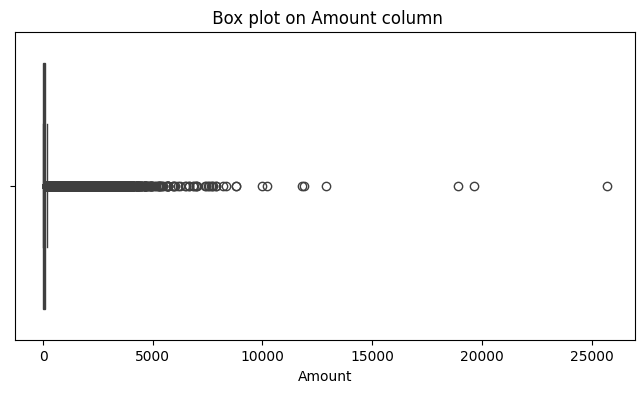

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(data = credit , x = 'Amount')
plt.title(" Box plot on Amount column")
plt.show()


In [ ]:
q1 = credit['Amount'].quantile(0.25)
q2 = credit['Amount'].quantile(0.5)
q3 = credit['Amount'].quantile(0.75)
iqr = q3-q1
minimum =  q1 - 1.5*iqr
maximum = q1 + 1.5*iqr
outlier = credit[(credit.Amount <=minimum) | (credit.Amount >= maximum)]

In [ ]:
print(q1 , q2 , q3, minimum , maximum )

5.6 22.0 77.16499999999999 -101.7475 112.94749999999999


In [ ]:
print("Length of the outlier: ",len(outlier))

Length of the outlier:  51706


In [ ]:
print("percentage of outlier of the total data : ",(len(outlier)/credit.shape[0])*100)

percentage of outlier of the total data :  18.154750409926724


In [ ]:
clean_data = credit[(credit.Amount >= minimum)&(credit.Amount <= maximum)]

In [ ]:
print("percentage of data without outliers:",(clean_data.shape[0]/ credit.shape[0])*100)

percentage of data without outliers: 81.84524959007328


# Zscore :

<Axes: xlabel='Amount', ylabel='Density'>

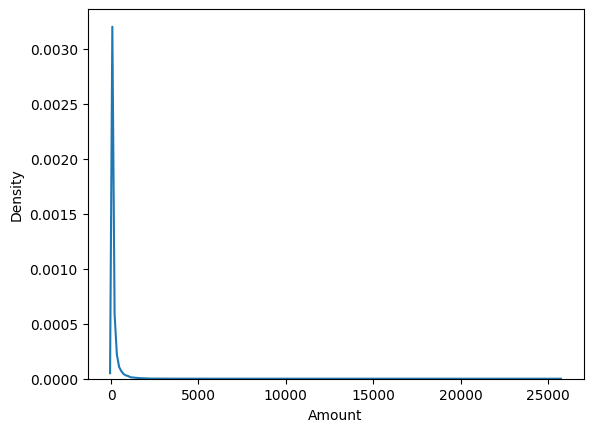

In [ ]:
sns.kdeplot(data=credit ,x = 'Amount') # zscore not used because data is right skew and pointed .